In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df = 'used_cars.csv'
data = pd.read_csv(df)

In [44]:
data.shape

(4009, 12)

In [45]:
data.columns

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='object')

In [46]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [47]:
data.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [48]:
data['milage'] = (data['milage']
                .str.replace(r'[^\d]', '', regex=True)
                .astype(int))

data['price'] = (data['price']
               .str.replace(r'[^\d]', '', regex=True)
               .astype(int))
print(data['price'])
print(data['milage'])

0        10300
1        38005
2        54598
3        15500
4        34999
         ...  
4004    349950
4005     53900
4006     90998
4007     62999
4008     40000
Name: price, Length: 4009, dtype: int64
0       51000
1       34742
2       22372
3       88900
4        9835
        ...  
4004      714
4005    10900
4006     2116
4007    33000
4008    43000
Name: milage, Length: 4009, dtype: int64


In [49]:
data.describe()

,model_year,milage,price
count,4009.000000,4009.000000,4.009000e+03
mean,2015.515590,64717.551010,4.455319e+04
std,6.104816,52296.599459,7.871064e+04
min,1974.000000,100.000000,2.000000e+03
25%,2012.000000,23044.000000,1.720000e+04
50%,2017.000000,52775.000000,3.100000e+04
75%,2020.000000,94100.000000,4.999000e+04
max,2024.000000,405000.000000,2.954083e+06


In [50]:
data.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [58]:
data['clean_title'] = data['clean_title'].fillna('unknown')
data['accident'] = data['accident'].fillna('unknown')
data['fuel_type'] = data['fuel_type'].fillna('unknown')  

Оставил потому что пропуски стоят не в целевом признаке

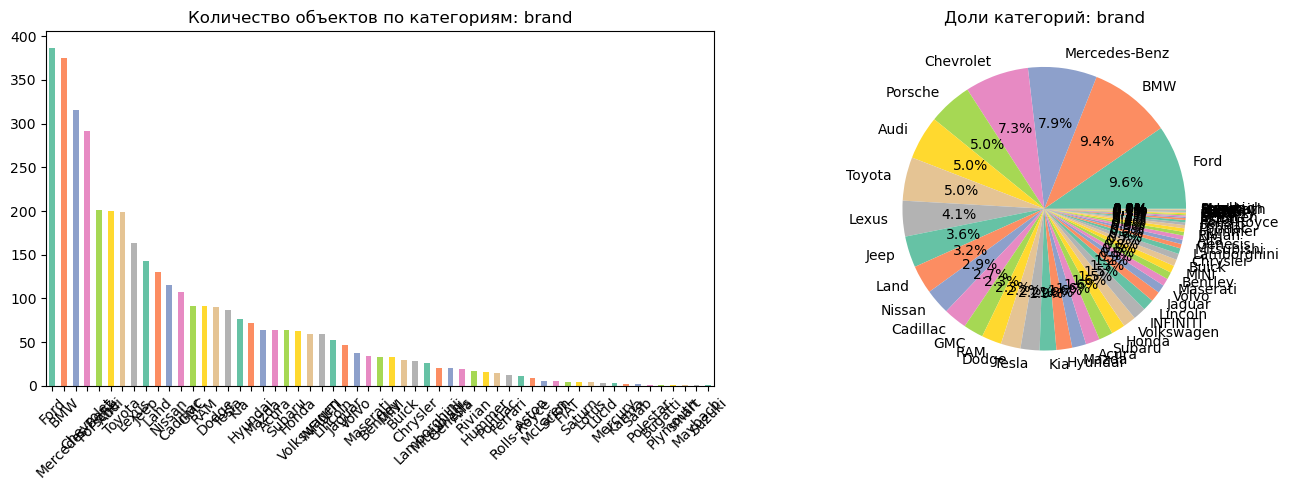

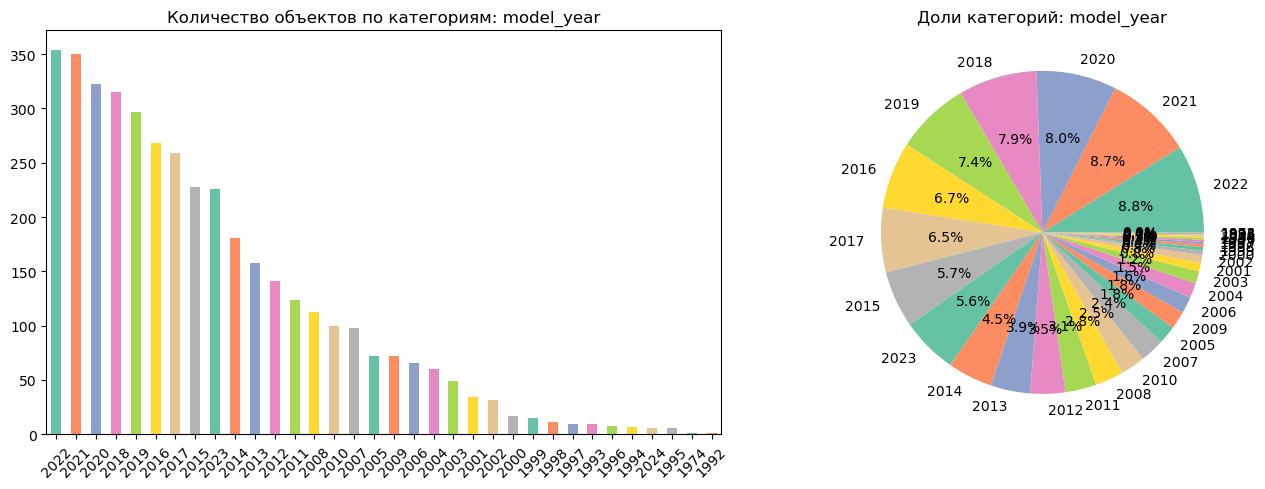

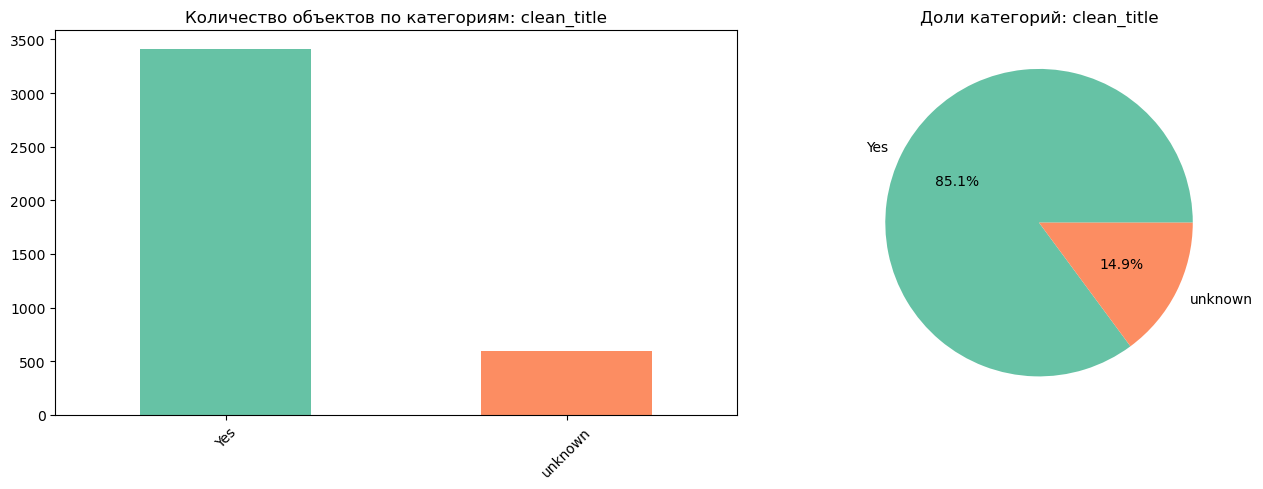

In [59]:

low_card_cols = ['brand', 'model_year', 'clean_title']  

for col in low_card_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    counts = data[col].value_counts(dropna=False)  
    counts.plot.bar(ax=axes[0], color=sns.color_palette('Set2'))
    axes[0].set_title(f'Количество объектов по категориям: {col}')
    axes[0].tick_params(axis='x', rotation=45)

    data[col].value_counts(normalize=True, dropna=False).plot.pie(
        ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
    axes[1].set_ylabel('')
    axes[1].set_title(f'Доли категорий: {col}')

    plt.tight_layout()
    plt.show()

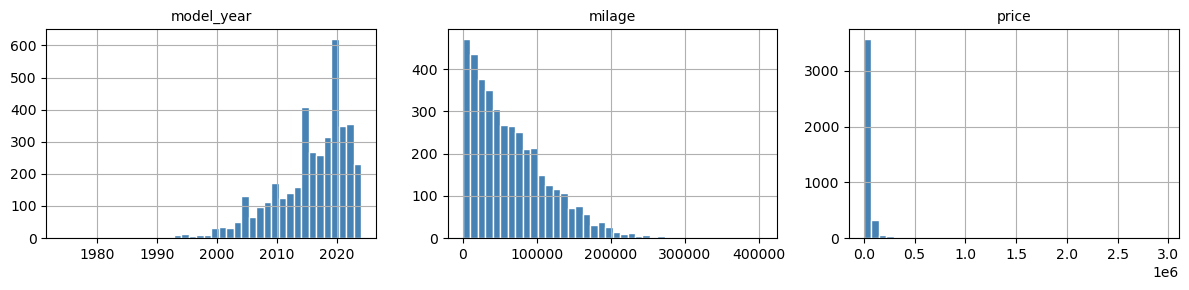

In [60]:
numeric_cols = data.select_dtypes(include=np.number).columns.tolist()
n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4

fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 3))
axes = np.atleast_1d(axes).flatten()  

for i, col in enumerate(numeric_cols):
    data[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')  
    axes[i].set_title(col, fontsize=10) 

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Видим что есть выброс в цене

In [61]:
print(data['price'].describe())
data.sort_values('price', ascending=False).head(10)

count    4.009000e+03
mean     4.455319e+04
std      7.871064e+04
min      2.000000e+03
25%      1.720000e+04
50%      3.100000e+04
75%      4.999000e+04
max      2.954083e+06
Name: price, dtype: float64


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
693,Maserati,Quattroporte Base,2005,32000,Gasoline,394.0HP 4.2L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Red,Beige,At least 1 accident or damage reported,Yes,2954083
229,Bugatti,Veyron 16.4 Grand Sport,2011,6330,Gasoline,8.0L W16 64V GDI DOHC Twin Turbo,7-Speed Automatic with Auto-Shift,White,White,None reported,Yes,1950995
3046,Porsche,Carrera GT Base,2005,4400,Gasoline,605.0HP 5.7L 10 Cylinder Engine Gasoline Fuel,6-Speed M/T,Gray,Black,None reported,Yes,1599000
1356,Lamborghini,Aventador SVJ Base,2021,6987,Gasoline,6.5L V12 48V MPFI DOHC,7-Speed,–,Nero Ade,None reported,Yes,749950
624,Rolls-Royce,Cullinan,2022,398,Gasoline,6.7L V12 48V GDI DOHC Twin Turbo,8-Speed Automatic,Silver,Charles Blue,None reported,Yes,695000
979,Lamborghini,Aventador SVJ Base,2019,6929,Gasoline,759.0HP 6.5L 12 Cylinder Engine Gasoline Fuel,A/T,Blue,Black,None reported,Yes,649999
1615,Rolls-Royce,Phantom,2023,1560,–,–,–,Tempest,Cobalt Blue,None reported,Yes,599995
1508,Rolls-Royce,Phantom,2018,7585,Gasoline,6.8L V12 48V GDI DOHC Twin Turbo,8-Speed Automatic,–,–,None reported,Yes,599000
3655,Lamborghini,Aventador S Base,2018,5858,Gasoline,729.0HP 6.5L 12 Cylinder Engine Gasoline Fuel,7-Speed A/T,White,Gray,None reported,Yes,491836
1061,Dodge,Viper GTC,2017,1389,Gasoline,645.0HP 8.4L 10 Cylinder Engine Gasoline Fuel,M/T,Black,Black,None reported,Yes,489995


Оказалось что это не выброс-такие машины действительно столько стоят

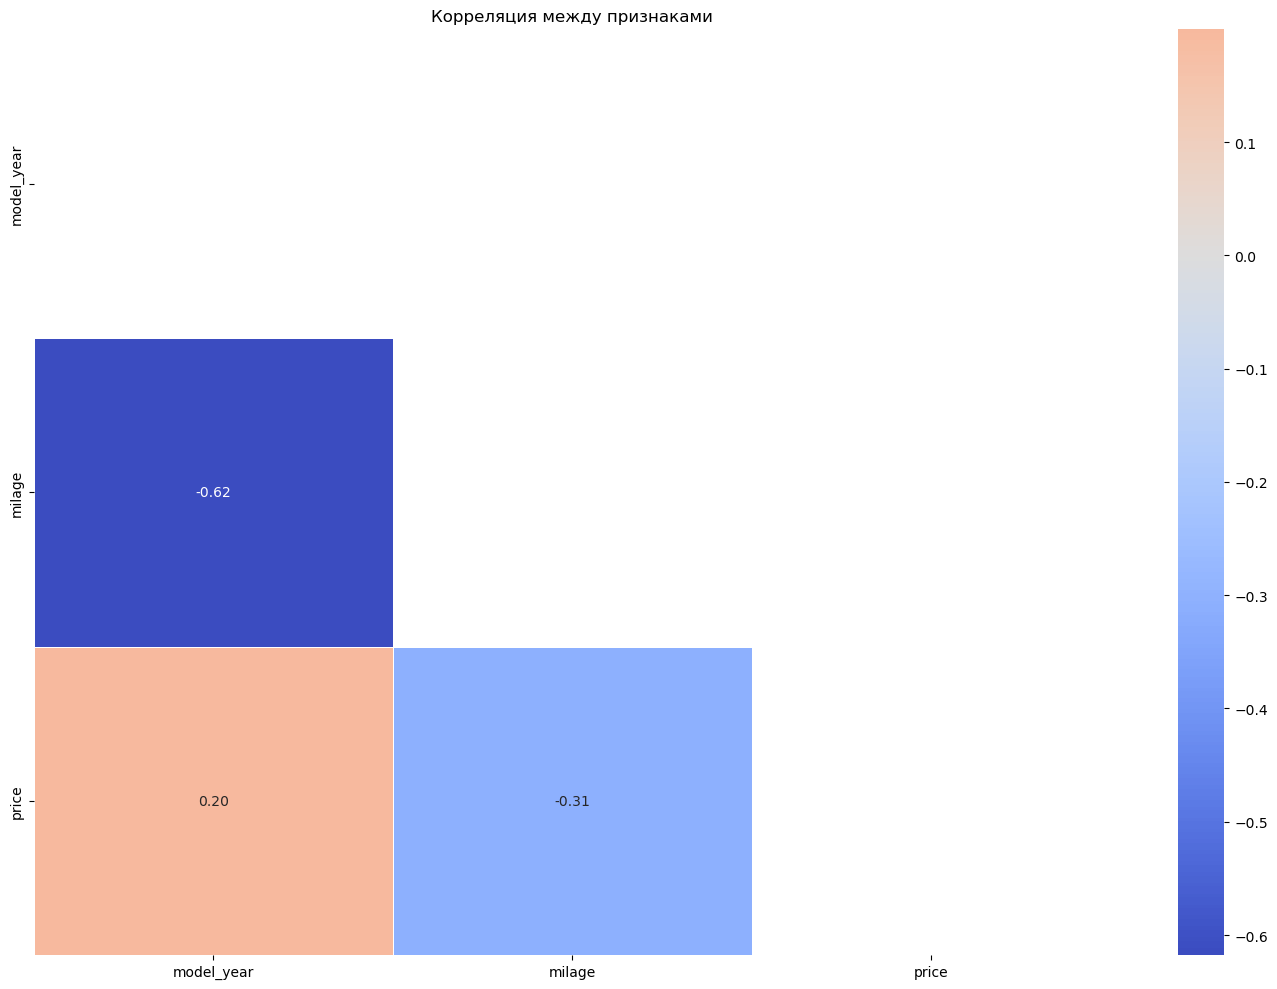

In [62]:
plt.figure(figsize=(14, 10))
corr = data[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()

Связь с ценой слабая-предсказывать цену будут плохо.Цена зависит возможно больше от категориальных признаков

In [63]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder

X = data.drop(columns=['price']).copy()
y = data['price']

cat_cols = X.select_dtypes(include='object').columns
for col in cat_cols:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

discrete_mask = [col in cat_cols for col in X.columns]
mi = mutual_info_regression(X, y, discrete_features=discrete_mask, random_state=42)

mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)
print(mi_series)

model           1.085641
engine          1.035982
milage          0.330578
model_year      0.322649
transmission    0.258790
brand           0.251524
int_col         0.109262
clean_title     0.100343
ext_col         0.094052
fuel_type       0.053664
accident        0.043262
dtype: float64


Действительно-от категориальных признаков зависимость сильнее

In [ ]:
Смотрию на признак engine(какая информация есть или нет)

In [72]:
missing = data['engine_cylinders'].isna()
data.loc[missing, 'engine_cylinders'] = data.loc[missing, 'engine'].str.extract(r'H(\d+)')[0].astype(float)
# W16 (Bugatti и т.п.)
missing = data['engine_cylinders'].isna()
data.loc[missing, 'engine_cylinders'] = data.loc[missing, 'engine'].str.extract(r'W(\d+)')[0].astype(float)
missing = data['engine_cylinders'].isna()
data.loc[missing, 'engine_cylinders'] = data.loc[missing, 'engine'].str.extract(r'\bI-(\d+)')[0].astype(float)
print(data['engine_cylinders'].isna().sum())

237


In [112]:
missing = data['engine_cylinders'].isna()
print('всего осталось:', missing.sum())
print('из них электро:', data[missing]['engine'].str.contains('Electric|AH', case=False, na=False).sum())
print(data[missing]['engine'].head(30).tolist())

всего осталось: 214
из них электро: 0
['3.5 Liter DOHC', '2.4 Liter', '2.0 Liter Supercharged', '3.0 Liter Turbo', '1.8 Liter', '3.0 Liter Turbo', '3.5 Liter SOHC', '4.4 Liter DOHC Twin Turbo', '2.0 Liter', '3.0 Liter DOHC Turbo', '2.0 Liter', '2.0 Liter Turbo', '4.4 Liter Twin Turbo', '3.0 Liter GTDI', '2.0 Liter Turbo', '3.0 Liter Turbo', '–', '3.0 Liter Twin Turbo', '3.0 Liter Turbo', '2.4 Liter', '4.7 Liter Twin Turbo', '5.4 Liter SC DOHC', '5.7 Liter', '1.5 Liter Turbo', '3.5 Liter GTDI', '–', '5.6 Liter', '2.0 Liter TFSI', '2.0 Liter DOHC Turbo', '3.0 Liter']


In [76]:
data['engine_liters'] = data['engine'].str.extract(r'([\d.]+)\s*L\b')[0].astype(float)
data['engine_liters'] = data['engine_liters'].fillna(
    data['engine'].str.extract(r'([\d.]+)\s*Liter')[0].astype(float)
)
ev_mask = data['engine'].str.contains('Electric|AH', case=False, na=False)
data.loc[ev_mask, 'engine_liters'] = data.loc[ev_mask, 'engine_liters'].fillna(0)
print('пропусков литров:', data['engine_liters'].isna().sum())

пропусков литров: 54


In [113]:
missing_l = data['engine_liters'].isna()
print('всего:', missing_l.sum())
print('электро:', data[missing_l]['engine'].str.contains('Electric|AH', case=False, na=False).sum())
print(data[missing_l]['engine'].head(40).tolist())

всего: 50
электро: 0
['V6', 'V6', '–', '–', '–', '–', 'V8', '–', '–', '–', '–', '–', '–', '–', '–', '–', '–', '–', '–', '–', '–', '–', '–', '–', '–', '–', '–', '–', '12 Cylinder Engine', '–', '–', '–', '–', '–', '–', 'I4', '–', '–', '–', '–']


In [78]:
ev_pattern = 'Electric|AH|Battery|Dual Motor'
ev_mask = data['engine'].str.contains(ev_pattern, case=False, na=False)
data.loc[ev_mask, 'engine_liters'] = data.loc[ev_mask, 'engine_liters'].fillna(0)
data.loc[ev_mask, 'engine_cylinders'] = data.loc[ev_mask, 'engine_cylinders'].fillna(0)
data.loc[ev_mask, 'fuel_type'] = 'Electric'
print('пропусков литров:', data['engine_liters'].isna().sum())

пропусков литров: 50


In [79]:
print('пропусков HP:', data['engine_hp'].isna().sum())
print(data[data['engine_hp'].isna()]['engine'].head(20).tolist())

пропусков HP: 808
['3.8L V6 24V GDI DOHC', '3.5 Liter DOHC', '2.0L I4 16V GDI DOHC Turbo', '2.4 Liter', 'V6', '2.0 Liter Supercharged', '2.0L I4 16V GDI DOHC Turbo', '3.0 Liter Turbo', '3.5L V6 24V PDI DOHC Twin Turbo', '1.8 Liter', '2.0L I4 16V GDI DOHC Turbo Flexible Fuel', '120 AH', '3.0 Liter Turbo', '3.5 Liter SOHC', '3.0L V6 Cylinder Engine Diesel Fuel', '4.4 Liter DOHC Twin Turbo', '5.3L V8 16V GDI OHV', '2.4L I4 16V GDI DOHC', '1.5L I3 12V GDI DOHC Turbo', '5.2L V10 40V PDI DOHC']


In [81]:
print(data[['engine_hp', 'engine_liters', 'engine_cylinders']].isna().sum())  
print(data['fuel_type'].value_counts(dropna=False)) 
print(data.shape) 

engine_hp           808
engine_liters        50
engine_cylinders    214
dtype: int64
Gasoline         3309
Electric          353
E85 Flex Fuel     139
Diesel            116
Hybrid             47
–                  45
Name: fuel_type, dtype: int64
(4009, 15)


In [82]:
data['fuel_type'] = data['fuel_type'].replace({'–': 'unknown', 'not supported': 'unknown'})
data['fuel_type'] = data['fuel_type'].fillna('unknown')
print(data['fuel_type'].value_counts(dropna=False))

Gasoline         3309
Electric          353
E85 Flex Fuel     139
Diesel            116
Hybrid             47
unknown            45
Name: fuel_type, dtype: int64


In [83]:
data['engine_hp_missing'] = data['engine_hp'].isna().astype(int)
print(data.columns.tolist())

['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title', 'price', 'engine_hp', 'engine_liters', 'engine_cylinders', 'engine_hp_missing']


In [ ]:
Убрал строку чтобы не было сильного выброса(самая огромная цена)

In [84]:
data = data[data['price'] < 2_000_000]  
print(data.shape, data['price'].max())

(4008, 16) 1950995


In [92]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

drop_cols = ['engine', 'price']

X = data.drop(columns=drop_cols)
y = data['price']
num_features = ['milage', 'model_year', 'engine_hp', 'engine_liters',
                'engine_cylinders', 'engine_hp_missing']
low_card_features = ['fuel_type', 'accident', 'clean_title']
high_card_features = ['brand', 'model', 'ext_col', 'int_col', 'transmission']

all_feats = num_features + low_card_features + high_card_features
print('признаков разложено:', len(all_feats))
print('признаков в X:', X.shape[1])
print('не разложены:', set(X.columns) - set(all_feats))
print('лишние в списках:', set(all_feats) - set(X.columns))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('train:', X_train.shape, 'test:', X_test.shape)

признаков разложено: 14
признаков в X: 14
не разложены: set()
лишние в списках: set()
train: (3206, 14) test: (802, 14)


In [88]:
!pip install category_encoders

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.0/82.0 kB 953.5 kB/s eta 0:00:000:0100:01


In [93]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from category_encoders import TargetEncoder
import numpy as np

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

low_card_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

high_card_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('target', TargetEncoder(smoothing=10))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_features),
    ('low', low_card_pipe, low_card_features),
    ('high', high_card_pipe, high_card_features)
])

X_check = preprocessor.fit_transform(X_train, y_train)
print('форма после препроцессинга:', X_check.shape)
print('есть ли NaN:', np.isnan(X_check).any())

форма после препроцессинга: (3206, 22)
есть ли NaN: False


In [116]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_validate, KFold
import numpy as np

cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

models = {
    'Ridge': Ridge(random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}

def eval_model(name, model, X, y):
    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])
    res = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    rmse = -res['test_rmse']
    mae = -res['test_mae']
    r2 = res['test_r2']
    print(f'{name}:')
    print(f'  RMSE: {rmse.mean():,.0f}')
    print(f'  MAE:  {mae.mean():,.0f}')
    print(f'  R2:   {r2.mean():.3f}')
    return {'rmse': rmse, 'mae': mae, 'r2': r2}

baseline_results = {}
for name, model in models.items():
    baseline_results[name] = eval_model(name, model, X_train, y_train)

Ridge:
  RMSE: 35,618
  MAE:  17,717
  R2:   0.500
GradientBoosting:
  RMSE: 33,122
  MAE:  14,276
  R2:   0.567


In [96]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42
)

imp_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])
imp_pipe.fit(X_tr, y_tr)

perm = permutation_importance(
    imp_pipe, X_val, y_val,
    n_repeats=10, random_state=42, n_jobs=-1,
    scoring='neg_root_mean_squared_error'
)

importance = pd.Series(perm.importances_mean, index=X_val.columns).sort_values(ascending=False)
print('Feature importance (permutation, по росту RMSE):')
print(importance)

Feature importance (permutation, по росту RMSE):
model                12997.268463
milage                2468.321557
int_col               1095.387700
model_year             581.376807
engine_hp              541.069610
engine_liters          502.868748
transmission           208.553866
engine_hp_missing       51.131445
brand                   32.240089
accident                12.424573
fuel_type                2.663211
clean_title             -2.667197
ext_col                -10.264425
engine_cylinders       -38.540393
dtype: float64


int_col оказываетсяя важен

In [117]:
top_features = ['model', 'milage', 'int_col', 'model_year', 'engine_hp', 'engine_liters']

num_top = ['milage', 'model_year', 'engine_hp', 'engine_liters']
high_card_top = ['model', 'int_col']
preprocessor_top = ColumnTransformer([
    ('num', num_pipe, num_top),
    ('high', high_card_pipe, high_card_top)
])

print('СОКРАЩЁННЫЙ НАБОР (6 признаков)')
reduced_results = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor_top), ('model', model)])
    res = cross_validate(pipe, X_train[top_features], y_train,
                         cv=cv, scoring=scoring, n_jobs=-1)
    rmse, mae, r2 = -res['test_rmse'], -res['test_mae'], res['test_r2']
    reduced_results[name] = {'rmse': rmse, 'mae': mae, 'r2': r2}
    print(f'{name}:')
    print(f'  RMSE: {rmse.mean():,.0f}')
    print(f'  MAE:  {mae.mean():,.0f}')
    print(f'  R2:   {r2.mean():.3f}')

СОКРАЩЁННЫЙ НАБОР (6 признаков)
Ridge:
  RMSE: 36,539
  MAE:  18,130
  R2:   0.474
GradientBoosting:
  RMSE: 33,582
  MAE:  14,499
  R2:   0.554
